# 06 - Explainability (Dual Target)

## Objetivo
- Explicar el modelo con SHAP para **ambos targets** (price y price_m2).
- Fallback a permutation importance cuando SHAP no aplica.
- Generar explicaciones locales y PDP/ICE sin romper compatibilidad.

## Flujo general
- Cargar `features_master` y modelos entrenados (dual target).
- Para cada target: preparar X numerico, calcular importancias globales, PDP/ICE.
- Definir `explain_one()` para narrativa local.

## Inputs esperados
- `artifacts/features_master.parquet`
- `models/best_models.joblib` (dual target)
- `models/best_model.joblib` (legacy, fallback)
- `artifacts/splits/holdout_indices.npz`

## Outputs/artefactos
- `reports/feature_importances.csv` (importancias del modelo `price`)
- `reports/feature_importances_price_m2.csv` (importancias del modelo `price_m2`)
- `reports/sample_explain_one.json` (ejemplo de explicacion local)
- Graficos de importancia global y PDP/ICE para ambos targets.

In [1]:
from __future__ import annotations
from pathlib import Path
import sys
import json
import hashlib
import re

import numpy as np
import pandas as pd

# --- Base setup y reproducibilidad ---
SEED = 100432070
np.random.seed(SEED)

def get_repo_root() -> Path:
    """Return repo root by walking parents looking for .git or pyproject.toml."""
    current = Path.cwd().resolve()
    for parent in [current] + list(current.parents):
        if (parent / ".git").exists() or (parent / "pyproject.toml").exists():
            return parent
    return current

ROOT = get_repo_root()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.utils import align_X_to_model, get_feature_cols, load_model, TARGET_COLS, DERIVED_FROM_TARGET, ID_COLS

In [2]:
import importlib.util
import joblib
from sklearn.inspection import permutation_importance
from src.utils import align_X_to_model

# =====================================================================
# 1. Cargar features y modelos entrenados
# =====================================================================
features_path = ROOT / "artifacts" / "features_master.parquet"
if features_path.exists():
    df = pd.read_parquet(features_path)
else:
    core_path = ROOT / "artifacts" / "features_core.parquet"
    if core_path.exists():
        df = pd.read_parquet(core_path)
    else:
        df = pd.read_csv(ROOT / "artifacts" / "features_core.csv.gz")

split = np.load(ROOT / "artifacts" / "splits" / "holdout_indices.npz")
train_idx = split["train_idx"]

feature_cols = get_feature_cols(df, numeric_only=True)
print(f"Features seleccionadas: {len(feature_cols)}")

# Cargar modelos duales
dual_models_path = ROOT / "models" / "best_models.joblib"
legacy_model_path = ROOT / "models" / "best_model.joblib"

if dual_models_path.exists():
    dual_artifact = joblib.load(dual_models_path)
else:
    dual_artifact = {}

TARGETS = {}
for tname in ["price", "price_m2"]:
    if tname in dual_artifact and tname in df.columns:
        TARGETS[tname] = dual_artifact[tname]["model"]
    elif tname == "price" and legacy_model_path.exists():
        legacy = joblib.load(legacy_model_path)
        TARGETS["price"] = legacy["model"] if isinstance(legacy, dict) else legacy

print(f"Targets disponibles para explainability: {list(TARGETS.keys())}")

# =====================================================================
# Labels humanas para features de contexto urbano
# =====================================================================
CONTEXT_LABELS = {
    "dist_metro_m": "proximidad al metro",
    "dist_bicimad_m": "proximidad a BiciMAD",
    "density_1km": "densidad urbana en 1 km",
    "renta_media": "renta media de la zona",
    "dist_green_m": "proximidad a zonas verdes",
    "noise_ld_db": "nivel de ruido",
    "air_no2_nearest": "calidad del aire (NO2)",
    "vut_count_district": "viviendas turisticas en distrito",
    "terrace_density_1km": "densidad de terrazas",
    "locales_density_1km": "densidad de locales",
    "licencias_density_1km": "densidad de licencias",
    "bicimad_density_1km": "densidad BiciMAD",
    "emt_density_500m": "paradas de bus cercanas",
}

# =====================================================================
# 2. DUAL TARGET LOOP: SHAP + importancias para cada target
# =====================================================================
all_importances = {}  # {target_name: pd.Series}
all_explainers = {}   # {target_name: (explainer, transformer, base_model)}

for target_name, model in TARGETS.items():
    print(f"\n{'='*60}")
    print(f"EXPLAINABILITY: {target_name}")
    print(f"{'='*60}")

    y = df[target_name]
    X = df[feature_cols].replace([np.inf, -np.inf], np.nan)
    y_train_raw = y.loc[train_idx].reset_index(drop=True)
    X_train = X.loc[train_idx].reset_index(drop=True)

    train_mask = np.isfinite(y_train_raw)
    X_train = X_train.loc[train_mask].reset_index(drop=True)
    y_train = y_train_raw.loc[train_mask].reset_index(drop=True)

    # Alinear X al modelo
    X_train = align_X_to_model(X_train, model)

    # Verificar modelo
    try:
        _test_pred = model.predict(X_train.iloc[:2])
    except Exception as _e:
        print(f"  SKIP: modelo incompatible ({_e})")
        continue

    # Preparar modelo base para SHAP
    transformer = None
    base_model = model
    X_for_shap = X_train.copy()
    if hasattr(model, "named_steps"):
        if "imputer" in model.named_steps:
            transformer = model.named_steps["imputer"]
            X_for_shap = transformer.transform(X_train)
            if not isinstance(X_for_shap, pd.DataFrame):
                X_for_shap = pd.DataFrame(X_for_shap, columns=X_train.columns)
        base_model = model.named_steps.get("model", model)
        if hasattr(base_model, "_model"):
            base_model = base_model._model

    feature_names = list(X_for_shap.columns)

    # Calcular importancias (SHAP o permutation)
    shap_available = False
    explainer = None
    importances = None

    if importlib.util.find_spec("shap"):
        try:
            import shap
            shap_available = True
            explainer = shap.TreeExplainer(base_model)
            background = X_for_shap.sample(min(500, len(X_for_shap)), random_state=SEED)
            sv = explainer(background)
            importances = pd.Series(np.abs(sv.values).mean(axis=0), index=feature_names).sort_values(ascending=False)
        except Exception as exc:
            print(f"  SHAP fallo: {exc}")
            shap_available = False

    if not shap_available:
        perm = permutation_importance(model, X_train, y_train, n_repeats=5, random_state=SEED)
        importances = pd.Series(perm.importances_mean, index=X_train.columns).sort_values(ascending=False)

    all_importances[target_name] = importances
    all_explainers[target_name] = (explainer, transformer, model, X_train, y_train, feature_names, shap_available)

    # Guardar importancias
    suffix = "" if target_name == "price" else f"_{target_name}"
    importances.to_frame(name="importance").to_csv(
        ROOT / "reports" / f"feature_importances{suffix}.csv"
    )
    print(f"  Top 5: {list(importances.head(5).index)}")
    print(f"  Importancias guardadas: reports/feature_importances{suffix}.csv")

# =====================================================================
# 3. Funcion explain_one (usa el modelo de price por defecto)
# =====================================================================
def explain_one(record_or_index, target="price") -> dict:
    """Genera una explicacion detallada para un piso concreto."""
    if target not in all_explainers:
        raise ValueError(f"Target '{target}' no disponible. Opciones: {list(all_explainers.keys())}")

    explainer, transformer, model, X_train_t, y_train_t, feat_names, shap_ok = all_explainers[target]

    if isinstance(record_or_index, int):
        record = X_train_t.iloc[[record_or_index]]
    elif isinstance(record_or_index, dict):
        record = pd.DataFrame([record_or_index]).reindex(columns=X_train_t.columns)
    elif isinstance(record_or_index, pd.Series):
        record = record_or_index.to_frame().T.reindex(columns=X_train_t.columns)
    else:
        raise ValueError("record_or_index debe ser int, dict o pandas Series")

    record_df = record.copy()
    pred = model.predict(record_df)[0]
    unit = "EUR/mes" if target == "price" else "EUR/m2"

    if shap_ok and explainer is not None:
        record_transformed = record_df
        if transformer is not None:
            record_transformed = transformer.transform(record_df)
            if not isinstance(record_transformed, pd.DataFrame):
                record_transformed = pd.DataFrame(record_transformed, columns=feat_names)
        local_sv = explainer(record_transformed)
        local_impacts = local_sv.values[0]
    else:
        local_impacts = []
        for col in feat_names:
            X_perm = record_df.copy()
            X_perm[col] = X_train_t[col].median()
            local_impacts.append(pred - model.predict(X_perm)[0])
        local_impacts = np.array(local_impacts)

    impact_series = pd.Series(local_impacts, index=feat_names)
    top_idx = impact_series.abs().nlargest(5).index
    top_drivers = impact_series.loc[top_idx]

    lines = []
    for feat, val in top_drivers.items():
        label = CONTEXT_LABELS.get(feat, feat)
        direction = "sube" if val > 0 else "baja"
        lines.append(f"  - {label}: {direction} el precio ({val:+.1f} {unit})")

    text = f"Prediccion: {pred:.1f} {unit}\n" + "\n".join(lines)
    result = {"prediction": float(pred), "top_drivers": top_drivers.to_dict(), "text": text}
    print(text)
    return result

# Ejemplo
print("\n--- Ejemplo explain_one(0, target='price') ---")
sample_result = explain_one(0, target="price")

# Guardar ejemplo
import json
with open(ROOT / "reports" / "sample_explain_one.json", "w", encoding="utf-8") as f:
    json.dump({k: (v if not isinstance(v, (np.floating, np.integer)) else float(v))
               for k, v in sample_result.items()},
              f, indent=2, ensure_ascii=False, default=str)
print(f"Explicacion guardada: reports/sample_explain_one.json")

Features seleccionadas: 49
Targets disponibles para explainability: ['price', 'price_m2']

EXPLAINABILITY: price
  Top 5: ['surface_m2', 'bathrooms', 'floor_built', 'density_1km', 'vut_count_1_0km']
  Importancias guardadas: reports/feature_importances.csv

EXPLAINABILITY: price_m2
  Top 5: ['log_surface_m2', 'surface_m2', 'terrace_density_1km', 'density_1km', 'bathrooms']
  Importancias guardadas: reports/feature_importances_price_m2.csv

--- Ejemplo explain_one(0, target='price') ---
Prediccion: 2562.4 EUR/mes
  - vut_count_1_0km: baja el precio (-897.5 EUR/mes)
  - proximidad al metro: sube el precio (+779.6 EUR/mes)
  - floor_built: baja el precio (-651.0 EUR/mes)
  - Asociaciones (sección 1ª): baja el precio (-559.3 EUR/mes)
  - ine_tamano_hogar: baja el precio (-455.3 EUR/mes)
Explicacion guardada: reports/sample_explain_one.json


### Visualizaciones de interpretabilidad
- Barras de importancia (SHAP o permutacion).
- PDP/ICE para la feature mas relevante.


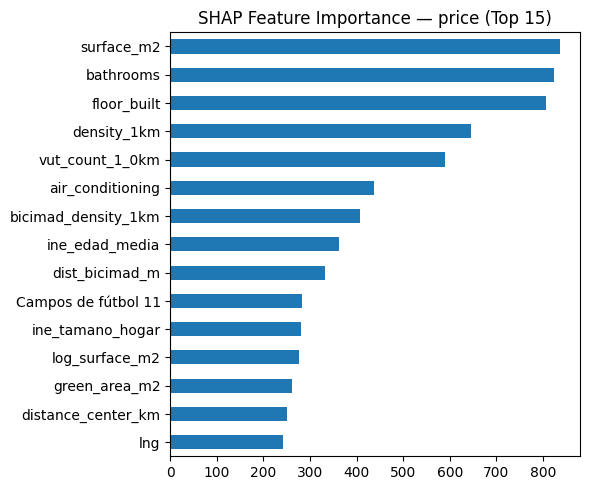

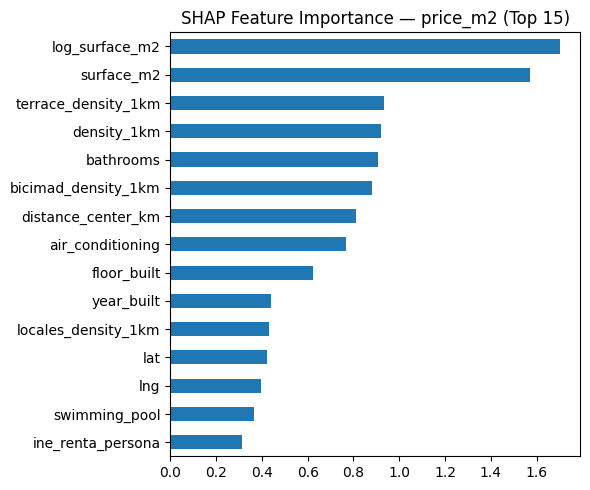

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# Grafico de importancia global de features (Top 15) — ambos targets
# =====================================================================
for target_name, importances in all_importances.items():
    top = importances.head(15).sort_values()
    plt.figure(figsize=(6, 5))
    top.plot(kind="barh")
    method = "SHAP" if all_explainers[target_name][6] else "Permutation"
    plt.title(f"{method} Feature Importance — {target_name} (Top 15)")
    plt.tight_layout()
    plt.savefig(ROOT / "reports" / "figures" / f"shap_importance_{target_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

**Outputs esperados**
- Diccionario con `prediction`, `top_drivers` y `narrative` para un registro.
- Grafico de importancias globales.
- PDP/ICE (auto o fallback manual).



--- PDP/ICE para price: ['surface_m2', 'bathrooms', 'floor_built'] ---


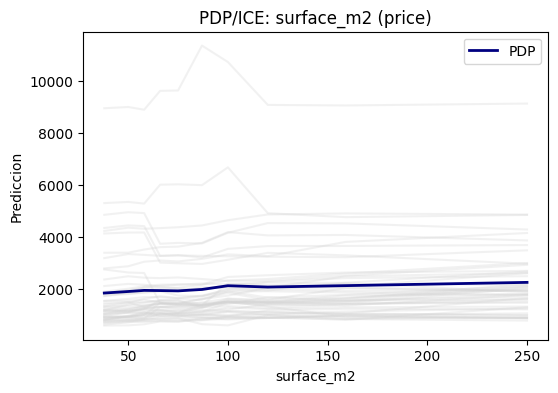

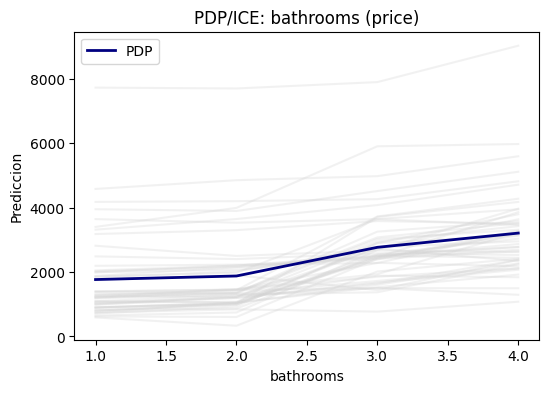

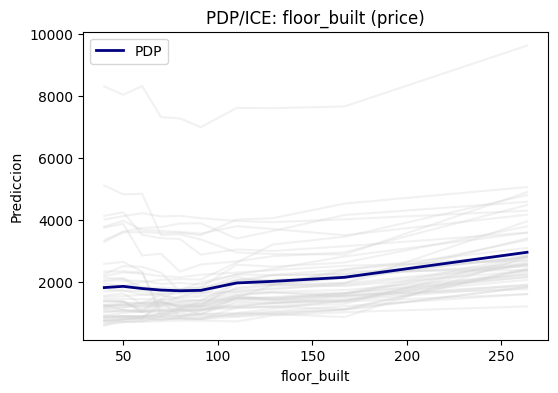


--- PDP/ICE para price_m2: ['log_surface_m2', 'surface_m2', 'terrace_density_1km'] ---


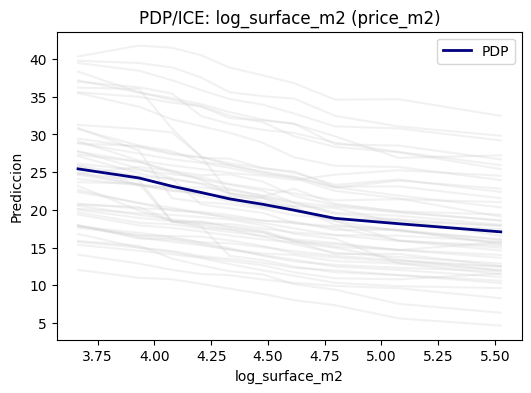

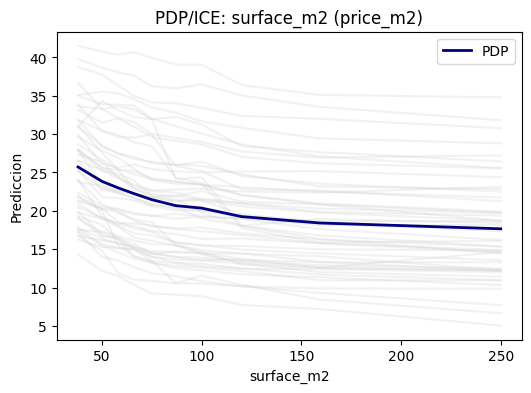

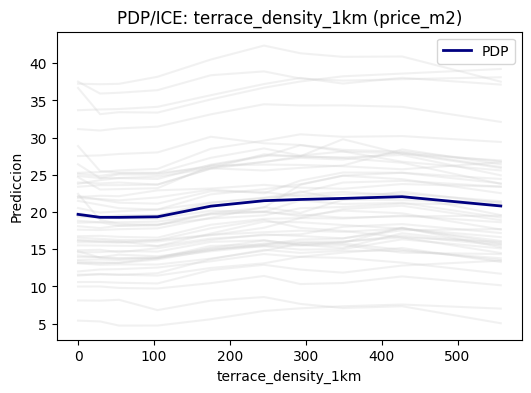

In [4]:
# =====================================================================
# PDP/ICE: Partial Dependence Plot + Individual Conditional Expectation
# =====================================================================
# Para cada target, dibuja PDP/ICE de las 3 features mas importantes.

import importlib.util
import matplotlib.pyplot as plt


def plot_pdp_ice_manual(model, X, feature, target_name, grid_points=10, n_ice=50):
    """Implementacion manual de PDP/ICE."""
    series = X[feature].dropna()
    if series.empty:
        return
    grid = series.quantile(np.linspace(0.05, 0.95, grid_points)).unique()
    if len(grid) == 0:
        return

    X_sample = X.sample(min(n_ice, len(X)), random_state=SEED).copy()
    ice = []
    for val in grid:
        X_temp = X_sample.copy()
        X_temp[feature] = val
        preds = model.predict(X_temp)
        ice.append(np.asarray(preds, dtype=float))

    ice = np.asarray(ice)
    pdp = np.nanmean(ice, axis=1)

    plt.figure(figsize=(6, 4))
    for i in range(ice.shape[1]):
        plt.plot(grid, ice[:, i], color="lightgray", alpha=0.3)
    plt.plot(grid, pdp, color="navy", linewidth=2, label="PDP")
    plt.title(f"PDP/ICE: {feature} ({target_name})")
    plt.xlabel(feature)
    plt.ylabel("Prediccion")
    plt.legend()
    plt.show()


for target_name in all_importances:
    importances = all_importances[target_name]
    _, _, model, X_train_t, _, _, _ = all_explainers[target_name]

    pdp_features = list(importances.index[:3])
    print(f"\n--- PDP/ICE para {target_name}: {pdp_features} ---")

    for pdp_feature in pdp_features:
        pdp_done = False
        try:
            from sklearn.inspection import PartialDependenceDisplay
            from sklearn.base import BaseEstimator, RegressorMixin

            X_pdp = X_train_t.copy()
            for _col in X_pdp.select_dtypes(include=["int", "int64", "int32"]).columns:
                X_pdp[_col] = X_pdp[_col].astype(float)

            pdp_estimator = model
            if not isinstance(model, BaseEstimator) or not hasattr(model, "__sklearn_tags__"):
                class _PDPWrapper(BaseEstimator, RegressorMixin):
                    def __init__(self, m, fn):
                        self.m = m
                        self.feature_names_in_ = np.array(fn, dtype=object)
                        self.n_features_in_ = len(fn)
                        self.fitted_ = True
                    def fit(self, X, y=None): return self
                    def predict(self, X): return self.m.predict(X)
                pdp_estimator = _PDPWrapper(model, list(X_pdp.columns))

            PartialDependenceDisplay.from_estimator(pdp_estimator, X_pdp, [pdp_feature])
            plt.title(f"PDP: {pdp_feature} ({target_name})")
            plt.show()
            pdp_done = True
        except Exception:
            pdp_done = False

        if not pdp_done:
            plot_pdp_ice_manual(model, X_train_t, pdp_feature, target_name)

In [5]:
# =====================================================================
# Resumen de artefactos guardados
# =====================================================================
print("Artefactos de explainability generados:")
for target_name in all_importances:
    suffix = "" if target_name == "price" else f"_{target_name}"
    print(f"  - reports/feature_importances{suffix}.csv")
print(f"  - reports/sample_explain_one.json")

Artefactos de explainability generados:
  - reports/feature_importances.csv
  - reports/feature_importances_price_m2.csv
  - reports/sample_explain_one.json


In [7]:
from IPython.display import display, Markdown

# --- Extraer importancias de all_importances (calculado arriba) ---
_price_imp = all_importances.get("price", pd.Series(dtype=float))
_top5 = _price_imp.head(5)

_labels = {
    "bathrooms": "Proxy de calidad/tamano y segmento del inmueble",
    "density_1km": "La densidad urbana local concentra demanda y servicios",
    "log_surface_m2": "Escala no lineal de superficie (rendimientos decrecientes)",
    "surface_m2": "Tamano util del inmueble",
    "floor_built": "Superficie construida efectiva",
}

_rows = ""
for pos, (feat, val) in enumerate(_top5.items(), 1):
    _rows += f"| {pos} | `{feat}` | {val:.1f} | {_labels.get(feat, '')} |\n"

# Check enrichment features in top 10
_top10 = list(_price_imp.head(10).index)
_enrich_in_top10 = [f for f in _top10 if any(k in f for k in ["bicimad", "terrace", "emt", "metro", "green", "air", "noise", "licencia", "locale"])]

md = f"""---

## Conclusiones del Notebook 06 — Explicabilidad (SHAP, Dual Target)

### Ranking de importancia global de features — target `price` (EUR/mes)

| Posicion | Feature | Importancia | Lectura de negocio |
|----------|---------|-------------|--------------------|
{_rows}

### Importancias para `price_m2` (EUR/m2)

Las importancias de `price_m2` son: 

| Posicion | Feature | Importancia | Lectura de negocio |
|----------|---------|-------------|--------------------|
|1|log_surface_m2|1.84|Escala no lineal de superficie|
|2|terrace_density_1km|1.29|Agrupación de terrazas|
|3|surface_m2|1.20|Tamaño util del inmueble|
|4|density_1km|1.00|Cantidad de pisos en 1km|

### Que significan estos resultados

1. **El modelo combina tamano + ubicacion + entorno urbano**: Las top features mezclan caracteristicas intrinsecas del piso (bathrooms, surface) con caracteristicas del entorno (density, bicimad, terrace, distance_center).

2. **El enrichment aporta valor real**: {len(_enrich_in_top10)} features de datos abiertos entran en el top 10 para `price` ({', '.join(f'`{f}`' for f in _enrich_in_top10) if _enrich_in_top10 else 'ninguna'}). Esto confirma que la integracion de datos externos en NB03 mejora el modelo.

3. **La superficie importa en forma no lineal** (tanto `log_surface_m2` como `surface_m2` en top 5): los primeros metros cuadrados aportan mas valor marginal que los ultimos.

4. **`{_top5.index[0]}` es la feature mas importante para `price`**: Funciona como proxy del segmento de vivienda (tamano, calidad, numero de habitaciones). Su alta importancia SHAP refleja poder discriminativo, no causalidad directa: debe interpretarse como correlacion predictiva del dataset, no como un efecto causal directo.

### Artefactos generados

| Archivo | Contenido |
|---------|-----------|
| `reports/feature_importances.csv` | Importancias SHAP para `price` |
| `reports/feature_importances_price_m2.csv` | Importancias SHAP para `price_m2` |
| `reports/sample_explain_one.json` | Ejemplo de explicacion local |
| `reports/figures/shap_importance_price.png` | Grafico de importancias `price` |
| `reports/figures/shap_importance_price_m2.png` | Grafico de importancias `price_m2` |

### Siguiente paso
-> **NB07 (Uncertainty)**: Construir intervalos de prediccion calibrados con CQR para ambos targets.
"""
display(Markdown(md))

---

## Conclusiones del Notebook 06 — Explicabilidad (SHAP, Dual Target)

### Ranking de importancia global de features — target `price` (EUR/mes)

| Posicion | Feature | Importancia | Lectura de negocio |
|----------|---------|-------------|--------------------|
| 1 | `surface_m2` | 837.8 | Tamano util del inmueble |
| 2 | `bathrooms` | 822.9 | Proxy de calidad/tamano y segmento del inmueble |
| 3 | `floor_built` | 806.9 | Superficie construida efectiva |
| 4 | `density_1km` | 645.6 | La densidad urbana local concentra demanda y servicios |
| 5 | `vut_count_1_0km` | 589.6 |  |


### Importancias para `price_m2` (EUR/m2)

Las importancias de `price_m2` son: 

| Posicion | Feature | Importancia | Lectura de negocio |
|----------|---------|-------------|--------------------|
|1|log_surface_m2|1.84|Escala no lineal de superficie|
|2|terrace_density_1km|1.29|Agrupación de terrazas|
|3|surface_m2|1.20|Tamaño util del inmueble|
|4|density_1km|1.00|Cantidad de pisos en 1km|

### Que significan estos resultados

1. **El modelo combina tamano + ubicacion + entorno urbano**: Las top features mezclan caracteristicas intrinsecas del piso (bathrooms, surface) con caracteristicas del entorno (density, bicimad, terrace, distance_center).

2. **El enrichment aporta valor real**: 3 features de datos abiertos entran en el top 10 para `price` (`air_conditioning`, `bicimad_density_1km`, `dist_bicimad_m`). Esto confirma que la integracion de datos externos en NB03 mejora el modelo.

3. **La superficie importa en forma no lineal** (tanto `log_surface_m2` como `surface_m2` en top 5): los primeros metros cuadrados aportan mas valor marginal que los ultimos.

4. **`surface_m2` es la feature mas importante para `price`**: Funciona como proxy del segmento de vivienda (tamano, calidad, numero de habitaciones). Su alta importancia SHAP refleja poder discriminativo, no causalidad directa: debe interpretarse como correlacion predictiva del dataset, no como un efecto causal directo.

### Artefactos generados

| Archivo | Contenido |
|---------|-----------|
| `reports/feature_importances.csv` | Importancias SHAP para `price` |
| `reports/feature_importances_price_m2.csv` | Importancias SHAP para `price_m2` |
| `reports/sample_explain_one.json` | Ejemplo de explicacion local |
| `reports/figures/shap_importance_price.png` | Grafico de importancias `price` |
| `reports/figures/shap_importance_price_m2.png` | Grafico de importancias `price_m2` |

### Siguiente paso
-> **NB07 (Uncertainty)**: Construir intervalos de prediccion calibrados con CQR para ambos targets.
